# Phase 6 - Transfer Learning with all visualizations

In [ ]:
"""

Transfer Learning :

This is the most important next step.
Because the results already showed:
	* baseline is weak
	* attention alone does not help
	* augmentation helps a bit, but not enough
So now we need a stronger idea:
1) first learn general EEG patterns from many subjects, then adapt to one subject
That is exactly what transfer learning does.

Understanding the TL:
Suppose I want to teach someone to recognize handwriting.

-> 'Normal training' will be like, I give them only one person’s notebook.
Here, the problem is :
	* too little data
	* they learn that one notebook too specifically

-> 'Transfer learning' will be like :
First:
	* show them notebooks from many people
Then:
	* show them the target person’s notebook
Now they learn:
	* general writing patterns first
	* then target-specific details later
That is the same idea here.


Heere, In my project, transfer learning means
STEPS:
1) Pretraining : Train the model using data from 'all subjects except the target subject'
2) Fine-tuning : Take that pretrained model and continue training it using the 'target subject training data'
3) Testing : Evaluate on the 'target subject test fold'
So, here in this case, for example if target subject is 'S14':
	* pretrain on all subjects except S14
	* then fine-tune on S14 training fold
	* then test on S14 test fold
That is the correct idea.

-->> This is stronger than plain subject-specific training.
Because, the model no longer starts from zero.
Instead, it starts with some general EEG knowledge learned from other people.
So even though S14 has little data, the model is not “blank” anymore.
It already knows some basic patterns.

scientifically, this direction is strong because it addresses the real issue:
	* not just “model design”
	* but 'lack of subject-specific data'
So transfer learning is directly targeting the bottleneck.


-->> transfer learning pipeline should look like
For one target subject, say S14 :

==>  Phase A — Build pretraining dataset
Take:
	* Subject 1
	* Subject 2
	* Subject 3
	* ...
	* all subjects except S14
Combine their valid filtered trials into one large dataset.
This becomes the pretraining data.

==>  Phase B — Build target subject dataset
Take only:
	* S14
Then do:
	* filtering
	* reshaping
	* label preparation
	* 5-fold split
This gives:
	* S14 train/test folds

==>  Phase C — Pretrain model
Train the baseline EEGNet on the combined non-target subjects.
This teaches the network general EEG feature extraction.

==>  Phase D — Fine-tune on target subject
Now take the pretrained model and continue training it on:
	* S14 training fold
Usually:
	* lower learning rate
	* smaller amount of training
	* maybe freeze some layers at first
We can keep it simple in the first implementation.

==>  Phase E — Test on target subject fold
Now evaluate on:
	* S14 test fold
This gives the transfer-learning result for that fold.

==>  Phase F — Repeat for all 5 folds
Repeat fine-tuning and testing using each target fold.
Then compute:
	* mean accuracy
	* standard deviation
Now,
1. Pretraining is done using other subjects
2. 5-fold CV is done on the target subject
That means:
	* target subject folds are still fair
	* the test fold is still unseen
	* no leakage from target test fold into pretraining
That is crucial.

=> What model should we use first for transfer learning?

First transfer learning model: 'Baseline EEGNet'
Not:
	* attention + transfer
	* augmentation + transfer
	* all combined
Because we must test one thing at a time.

So first we check:
-> does transfer learning alone help baseline EEGNet?
That is the clean next experiment.

=> What will be different from earlier notebooks?
Earlier notebooks used only one subject.
Now this notebook must handle:

Part 1 : All subject folders/files
Part 2 : A function to load and preprocess one subject
Part 3 : A function to build a combined pretraining dataset from all non-target subjects
Part 4 : Target subject fold training
So this notebook needs a little more organization.

What we will do first is, we will do in a order:
Step 1 & 2 : Creating a new notebook then, set the list of subject folders/files
Step 3 : Create one reusable function:
	* load one subject
	* preprocess it
	* return X and y
This is the most important reusable function.
Because for transfer learning, we need to load many subjects, not just one.
So this is the first building block.


"""

"\nTransfer Learning :  \n\nThis is the most important next step.\nBecause the results already showed:\n\t* baseline is weak\n\t* attention alone does not help\n\t* augmentation helps a bit, but not enough\nSo now we need a stronger idea:\n1) first learn general EEG patterns from many subjects, then adapt to one subject\nThat is exactly what transfer learning does.\n\nUnderstanding the TL: \nSuppose I want to teach someone to recognize handwriting.\n\n-> 'Normal training' will be like, I give them only one person’s notebook.\nHere, the problem is :\n\t* too little data\n\t* they learn that one notebook too specifically\n\n-> 'Transfer learning' will be like : \nFirst:\n\t* show them notebooks from many people\nThen:\n\t* show them the target person’s notebook\nNow they learn:\n\t* general writing patterns first\n\t* then target-specific details later\nThat is the same idea here.\n\n\nHeere, In my project, transfer learning means\nSTEPS: \n1) Pretraining : Train the model using data fro

In [ ]:
# ---------------------------------------
# step 1 : Mount Google Drive
# ---------------------------------------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ---------------------------------------
# step 2: importing the required libraries
# ---------------------------------------

import os
import random
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, DepthwiseConv2D
from tensorflow.keras.layers import AveragePooling2D, SeparableConv2D
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.utils import to_categorical

In [ ]:
# ---------------------------------------
# step 3 : Basic experiment settings
# ---------------------------------------


random_seed = 42
subject_file_name = "S14_EEG.mat"

dataset_folder = "/content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S14"
results_folder = "/content/drive/MyDrive/Colab_Notebooks/My_Project/Results_April2026"

number_of_signal_columns = 24576
number_of_channels = 6
number_of_samples_per_trial = 4096
number_of_folds = 5

batch_size = 16
number_of_epochs = 50
validation_size_inside_training = 0.2

In [ ]:
# ---------------------------------------
# step 4 : make results folder and fix randomness
# ---------------------------------------

# Creates the results folder if it doesn't exist
os.makedirs(results_folder, exist_ok=True)

np.random.seed(random_seed)
random.seed(random_seed)
tf.random.set_seed(random_seed)
print("==============================================")
print("Results folder is ready.")
print("Random seed is set.")
print("==============================================")

Results folder is ready.
Random seed is set.


In [ ]:
# ---------------------------------------
# step 5 : building the subject path and load the file
# ---------------------------------------

import scipy.io as sio

subject_file_name = "S14_EEG.mat"

subject_file_path = os.path.join(dataset_folder, subject_file_name)

print("==============================================")
print("Subject file path:", subject_file_path)
print("Does file exist?", os.path.exists(subject_file_path))
print("==============================================")
mat_data = sio.loadmat(subject_file_path)
print("==============================================")
print("\nThe .mat file loaded successfully.")
print("Available keys inside the file:", mat_data.keys())
print("==============================================")

Subject file path: /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S14/S14_EEG.mat
Does file exist? True

The .mat file loaded successfully.
Available keys inside the file: dict_keys(['__header__', '__version__', '__globals__', 'EEG'])


In [ ]:
# ---------------------------------------
# step 6 : extract EEG matrix and printing shape
# ---------------------------------------

eeg_matrix = mat_data["EEG"]
print("==============================================")
print("EEG matrix extracted.")
print("number_of_trials, number_of_columns are : ")
print("==============================================")
print("EEG matrix shape:", eeg_matrix.shape)
print("==============================================")

EEG matrix extracted.
number_of_trials, number_of_columns are : 
EEG matrix shape: (639, 24579)


In [ ]:
# ---------------------------------------
# step 7 : separating the signal data and metadata columns
# ---------------------------------------

number_of_signal_columns = 24576

signal_data = eeg_matrix[:, :number_of_signal_columns]
modality_column = eeg_matrix[:, number_of_signal_columns]
stimulus_column = eeg_matrix[:, number_of_signal_columns + 1]
artifact_column = eeg_matrix[:, number_of_signal_columns + 2]

print("==============================================")
print("Signal data shape:", signal_data.shape)
print("Modality column shape:", modality_column.shape)
print("Stimulus column shape:", stimulus_column.shape)
print("Artifact column shape:", artifact_column.shape)
print("==============================================")

print("Unique modality values:", np.unique(modality_column))
print("Unique stimulus values:", np.unique(stimulus_column))
print("Unique artifact values:", np.unique(artifact_column))
print("==============================================")


Signal data shape: (639, 24576)
Modality column shape: (639,)
Stimulus column shape: (639,)
Artifact column shape: (639,)
Unique modality values: [1. 2.]
Unique stimulus values: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
Unique artifact values: [1. 2.]


In [ ]:
# ---------------------------------------
# step 8: filtering only imagined speech and valid trials
# ---------------------------------------

valid_trial_mask = (modality_column == 1) & (artifact_column == 1)

filtered_signal_data = signal_data[valid_trial_mask]
filtered_labels = stimulus_column[valid_trial_mask]

print("==============================================")
print("Number of valid filtered trials:", len(filtered_labels))
print("Filtered signal shape:", filtered_signal_data.shape)
print("Filtered labels shape:", filtered_labels.shape)
print("==============================================")

print("Unique filtered labels:", np.unique(filtered_labels))
print("==============================================")

Number of valid filtered trials: 351
Filtered signal shape: (351, 24576)
Filtered labels shape: (351,)
Unique filtered labels: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]


In [ ]:
# ---------------------------------------
# step 9: reshape filtered signal into trial format
# ---------------------------------------


number_of_channels = 6
number_of_samples_per_trial = 4096

X = filtered_signal_data.reshape(-1, number_of_channels, number_of_samples_per_trial)
y = filtered_labels.astype(int)

print("==============================================")
print("X shape after reshape:", X.shape)
print("y shape:", y.shape)
print("==============================================")

X shape after reshape: (351, 6, 4096)
y shape: (351,)


In [ ]:
# ---------------------------------------
# step 10 : prepare labels for classification - shift labels to 0 ... 10
# ---------------------------------------

y = y - 1

number_of_classes = len(np.unique(y))
label_counts = pd.Series(y).value_counts().sort_index()

print("==============================================")
print("Unique labels after shifting to 0-based indexing:")
print(np.unique(y))
print("==============================================")

print("Number of classes:", number_of_classes)
print("==============================================")

print("Class counts:")
print(label_counts)
print("==============================================")

Unique labels after shifting to 0-based indexing:
[ 0  1  2  3  4  5  6  7  8  9 10]
Number of classes: 11
Class counts:
0     35
1     40
2     37
3     33
4     34
5     28
6     32
7     31
8     27
9     25
10    29
Name: count, dtype: int64


In [ ]:
# TL Step 1 — Define a reusable subject loading + preprocessing function


# ==============================================
# Transfer Learning - Step 1:
# reusable function to load and preprocess one subject
# ==============================================

def load_and_preprocess_subject(subject_file_path):
    # ------------------------------------------
    # Step 1.1: load the .mat file
    # ------------------------------------------
    mat_data = sio.loadmat(subject_file_path)

    # ------------------------------------------
    # Step 1.2: extract EEG matrix
    # ------------------------------------------
    eeg_matrix = mat_data["EEG"]

    # ------------------------------------------
    # Step 1.3: separate signal and metadata
    # ------------------------------------------
    signal_data = eeg_matrix[:, :number_of_signal_columns]
    modality_column = eeg_matrix[:, number_of_signal_columns]
    stimulus_column = eeg_matrix[:, number_of_signal_columns + 1]
    artifact_column = eeg_matrix[:, number_of_signal_columns + 2]

    # ------------------------------------------
    # Step 1.4: keep imagined speech + valid trials only
    # ------------------------------------------
    valid_trial_mask = (modality_column == 1) & (artifact_column == 1)

    filtered_signal_data = signal_data[valid_trial_mask]
    filtered_labels = stimulus_column[valid_trial_mask]

    # ------------------------------------------
    # Step 1.5: reshape into (trials, channels, samples)
    # ------------------------------------------
    X_subject = filtered_signal_data.reshape(
        -1,
        number_of_channels,
        number_of_samples_per_trial
    )

    # ------------------------------------------
    # Step 1.6: convert labels to integers and shift to 0-based
    # ------------------------------------------
    y_subject = filtered_labels.astype(int)
    y_subject = y_subject - 1

    return X_subject, y_subject

In [ ]:
# TL Step 2 — Test this function on S14 only

# ==============================================
# Transfer Learning - Step 2:
# test the reusable function on target subject S14
# ==============================================

target_subject_file_path = "/content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S14/S14_EEG.mat"

X_target, y_target = load_and_preprocess_subject(target_subject_file_path)

print("==============================================")
print("Target subject loaded successfully.")
print("X_target shape:", X_target.shape)
print("y_target shape:", y_target.shape)
print("Unique labels:", np.unique(y_target))
print("==============================================")

Target subject loaded successfully.
X_target shape: (351, 6, 4096)
y_target shape: (351,)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10]


In [ ]:
"""
Before pretraining and fine-tuning, we need one reusable function that can do this for any subject:
1. load the .mat file
2. extract the EEG matrix
3. separate signal and metadata
4. filter imagined speech + valid trials
5. reshape into (trials, channels, samples)
6. convert labels from 1...11 to 0...10
Earlier WE handled one subject manually.
Now transfer learning needs many subjects, so we need one clean function that does the same preprocessing every time.

AS PER THE ABOVE CODE,

def load_and_preprocess_subject(subject_file_path):
This creates one reusable function.
that means, it says - give me a subject file path, and I will return clean X and y
So later, instead of rewriting preprocessing for every subject, we can just call this function again and again.

Step 1.1
mat_data = sio.loadmat(subject_file_path)
This loads the .mat file.

Step 1.2
eeg_matrix = mat_data["EEG"]
This extracts the EEG matrix from the file.

Step 1.3
This separates:
  * EEG signal
  * modality
  * stimulus label
  * artifact

Step 1.4
valid_trial_mask = (modality_column == 1) & (artifact_column == 1)
This keeps only:
  * imagined speech trials
  * valid/clean trials
Same logic as before.

Step 1.5
X_subject = filtered_signal_data.reshape(...)

This reshapes the data into:
  * number of trials
  * 6 channels
  * 4096 samples
So now the data becomes model-ready.

Step 1.6
y_subject = y_subject - 1
This converts labels:
from 1...11
to 0...10
That is the same label format used in all earlier notebooks.

After defining it, step 2 says:
It checks whether the function works correctly for the subject you already know.
So this is just a sanity check.
*

For S14, the function returned:
  * X_target shape: (351, 6, 4096)
  * y_target shape: (351,)
  * labels from 0 to 10
So now we know: one reusable function can load and preprocess a subject correctly
That is the foundation we needed for transfer learning.

NEXT:

Now we must build a list of subject file paths.
Because transfer learning needs:
  *   one target subject for fine-tuning and testing
  *   all other subjects for pretraining
So now we will tell the notebook:
  *   where all subject folders are
  *   which one is the target
  *   which ones are the non-target subjects

"""

'\nBefore pretraining and fine-tuning, we need one reusable function that can do this for any subject:\n1. load the .mat file\n2. extract the EEG matrix\n3. separate signal and metadata\n4. filter imagined speech + valid trials\n5. reshape into (trials, channels, samples)\n6. convert labels from 1...11 to 0...10\nEarlier WE handled one subject manually.\nNow transfer learning needs many subjects, so we need one clean function that does the same preprocessing every time.\n\nAS PER THE ABOVE CODE, \n\ndef load_and_preprocess_subject(subject_file_path):\nThis creates one reusable function.\nthat means, it says - give me a subject file path, and I will return clean X and y\nSo later, instead of rewriting preprocessing for every subject, we can just call this function again and again.\n\nStep 1.1\nmat_data = sio.loadmat(subject_file_path)\nThis loads the .mat file.\n\nStep 1.2\neeg_matrix = mat_data["EEG"]\nThis extracts the EEG matrix from the file.\n\nStep 1.3\nThis separates:\n  * EEG si

In [ ]:
# TL — Step 3: Build subject file paths


# ==============================================
# Transfer Learning - Step 3:
# create subject file paths
# ==============================================

base_dataset_folder = "/content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada"

subject_names = [
    "S01", "S02", "S03", "S04", "S05", "S06", "S07",
    "S08", "S09", "S10", "S11", "S12", "S13", "S14", "S15"
]

subject_file_paths = {}

for subject_name in subject_names:
    subject_file_name = subject_name + "_EEG.mat"
    subject_file_path = os.path.join(base_dataset_folder, subject_name, subject_file_name)
    subject_file_paths[subject_name] = subject_file_path

print("==============================================")
print("Total subjects listed:", len(subject_file_paths))
print("==============================================")

for subject_name, subject_file_path in subject_file_paths.items():
    print(subject_name, "->", subject_file_path)

Total subjects listed: 15
S01 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S01/S01_EEG.mat
S02 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S02/S02_EEG.mat
S03 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S03/S03_EEG.mat
S04 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S04/S04_EEG.mat
S05 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S05/S05_EEG.mat
S06 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S06/S06_EEG.mat
S07 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S07/S07_EEG.mat
S08 -> /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S08/S08_EEG.mat
S09 -> /content/drive/

In [ ]:
# TL Step 4 — Check which files actually exist


# ==============================================
# Transfer Learning - Step 4:
# check which subject files actually exist
# ==============================================

existing_subject_file_paths = {}
missing_subjects = []

for subject_name, subject_file_path in subject_file_paths.items():
    if os.path.exists(subject_file_path):
        existing_subject_file_paths[subject_name] = subject_file_path
    else:
        missing_subjects.append(subject_name)

print("==============================================")
print("Existing subject files:", len(existing_subject_file_paths))
print("Missing subjects:", missing_subjects)
print("==============================================")

for subject_name, subject_file_path in existing_subject_file_paths.items():
    print(subject_name, "exists")

Existing subject files: 15
Missing subjects: []
S01 exists
S02 exists
S03 exists
S04 exists
S05 exists
S06 exists
S07 exists
S08 exists
S09 exists
S10 exists
S11 exists
S12 exists
S13 exists
S14 exists
S15 exists


In [ ]:
"""

base_dataset_folder = ...

This is the common root folder where all subject folders live.

So inside it, you have folders like:

S01
S02
...
S14
subject_names = [...]

This is the list of all subjects you want to include.

Right now I listed S01 to S15.

If your dataset has fewer or more subjects, we can adjust later.

subject_file_paths = {}

This creates an empty dictionary.

A dictionary is like a mapping table.

It will store things like:

"S01" -> full file path
"S02" -> full file path
The loop

For each subject:

build the file name
build the full path
store it in the dictionary
Important note

This assumes the file naming format is like:

S01_EEG.mat
S02_EEG.mat
...
S14_EEG.mat

That matches what you showed for S14.


as per step 4 code,

This is a safety check.

Because sometimes:

some subjects may be missing
some file names may be different

So before doing transfer learning, we verify which subject files are actually present.



As per the output, we see


Total subjects listed: 15
Existing subject files: 15
Missing subjects: none

So your dataset setup is clean.

That means we can now do transfer learning properly.

What we do next

Now we choose:

one target subject → the subject we want to evaluate on
all other subjects → the subjects used for pretraining

Since your current experiments were all on S14, we will keep that the same.

So:

Target subject
S14
Pretraining subjects
S01 to S13
S15

That keeps your comparison fair with all the previous notebook

"""

'\n\nbase_dataset_folder = ...\n\nThis is the common root folder where all subject folders live.\n\nSo inside it, you have folders like:\n\nS01\nS02\n...\nS14\nsubject_names = [...]\n\nThis is the list of all subjects you want to include.\n\nRight now I listed S01 to S15.\n\nIf your dataset has fewer or more subjects, we can adjust later.\n\nsubject_file_paths = {}\n\nThis creates an empty dictionary.\n\nA dictionary is like a mapping table.\n\nIt will store things like:\n\n"S01" -> full file path\n"S02" -> full file path\nThe loop\n\nFor each subject:\n\nbuild the file name\nbuild the full path\nstore it in the dictionary\nImportant note\n\nThis assumes the file naming format is like:\n\nS01_EEG.mat\nS02_EEG.mat\n...\nS14_EEG.mat\n\nThat matches what you showed for S14.\n\n\nas per step 4 code,\n\nThis is a safety check.\n\nBecause sometimes:\n\nsome subjects may be missing\nsome file names may be different\n\nSo before doing transfer learning, we verify which subject files are actual

In [ ]:
# TL — Step 5: Separate target and non-target subjects


# ==============================================
# Transfer Learning - Step 5:
# choose target subject and pretraining subjects
# ==============================================

target_subject_name = "S14"

target_subject_path = existing_subject_file_paths[target_subject_name]

pretraining_subject_paths = {}

for subject_name, subject_file_path in existing_subject_file_paths.items():
    if subject_name != target_subject_name:
        pretraining_subject_paths[subject_name] = subject_file_path

print("==============================================")
print("Target subject:", target_subject_name)
print("Target subject path:", target_subject_path)
print("Number of pretraining subjects:", len(pretraining_subject_paths))
print("==============================================")

for subject_name in pretraining_subject_paths:
    print(subject_name, "will be used for pretraining")

Target subject: S14
Target subject path: /content/drive/MyDrive/Colab_Notebooks/My_Project/imagined_speech/Base de Datos Habla Imaginada/S14/S14_EEG.mat
Number of pretraining subjects: 14
S01 will be used for pretraining
S02 will be used for pretraining
S03 will be used for pretraining
S04 will be used for pretraining
S05 will be used for pretraining
S06 will be used for pretraining
S07 will be used for pretraining
S08 will be used for pretraining
S09 will be used for pretraining
S10 will be used for pretraining
S11 will be used for pretraining
S12 will be used for pretraining
S13 will be used for pretraining
S15 will be used for pretraining


In [ ]:
# TL — Step 6: Load the target subject and create its 5 folds

# ==============================================
# Transfer Learning - Step 6:
# load target subject and create 5 folds
# ==============================================

X_target, y_target = load_and_preprocess_subject(target_subject_path)

print("==============================================")
print("Target subject loaded for transfer learning.")
print("X_target shape:", X_target.shape)
print("y_target shape:", y_target.shape)
print("Unique labels:", np.unique(y_target))
print("==============================================")

target_stratified_kfold = StratifiedKFold(
    n_splits=number_of_folds,
    shuffle=True,
    random_state=random_seed
)

target_fold_splits = list(target_stratified_kfold.split(X_target, y_target))

print("Number of target folds:", len(target_fold_splits))
print("==============================================")

for fold_number, (train_indices, test_indices) in enumerate(target_fold_splits, start=1):
    print("Fold", fold_number)
    print("Train size:", len(train_indices))
    print("Test size:", len(test_indices))
    print("----------------------------------------------")

Target subject loaded for transfer learning.
X_target shape: (351, 6, 4096)
y_target shape: (351,)
Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10]
Number of target folds: 5
Fold 1
Train size: 280
Test size: 71
----------------------------------------------
Fold 2
Train size: 281
Test size: 70
----------------------------------------------
Fold 3
Train size: 281
Test size: 70
----------------------------------------------
Fold 4
Train size: 281
Test size: 70
----------------------------------------------
Fold 5
Train size: 281
Test size: 70
----------------------------------------------


In [ ]:
"""
we now know
Total subjects listed: 15
Existing subject files: 15
Missing subjects: none

So your dataset setup is clean.

That means we can now do transfer learning properly.


Now we choose:

one target subject → the subject we want to evaluate on
all other subjects → the subjects used for pretraining

Since your current experiments were all on S14, we will keep that the same.

So:

Target subject
S14
Pretraining subjects
S01 to S13
S15

That keeps your comparison fair with all the previous notebooks.


As per the above step 5 code, we see:

target_subject_name = "S14"

This tells the notebook:

S14 is the subject we are testing in the transfer-learning experiment

So S14 is the one we will:

split into 5 folds
fine-tune on
test on
target_subject_path = ...

This gets the file path for S14.

pretraining_subject_paths = {}

This creates a new dictionary for all the non-target subjects.

The loop

This keeps every subject except S14 for pretraining.

So now the notebook has two groups:

one target subject
many pretraining subjects

That is exactly what we need.

We should see:

target subject = S14
number of pretraining subjects = 14


After Loading the target subjects and creating its 5 folds :
step 6 says:

Target subject loaded for transfer learning.


This is the same kind of fold creation you already did before, b
ut now we are making it explicit for the target subject in the transfer-learning setup.

So this gives us:

S14 data
S14 labels
S14 5-fold train/test splits

Later:

pretraining happens on other subjects
fine-tuning/testing happens on these S14 folds

"""

In [ ]:
# TL — Step 7: Build the combined pretraining dataset


# ==============================================
# Transfer Learning - Step 7:
# build combined pretraining dataset
# ==============================================

X_pretraining_list = []
y_pretraining_list = []

for subject_name, subject_file_path in pretraining_subject_paths.items():
    X_subject, y_subject = load_and_preprocess_subject(subject_file_path)

    X_pretraining_list.append(X_subject)
    y_pretraining_list.append(y_subject)

    print("Loaded", subject_name)
    print("  X shape:", X_subject.shape)
    print("  y shape:", y_subject.shape)
    print("  Number of trials:", len(y_subject))
    print("----------------------------------------------")

X_pretraining = np.concatenate(X_pretraining_list, axis=0)
y_pretraining = np.concatenate(y_pretraining_list, axis=0)

print("==============================================")
print("Combined pretraining dataset ready.")
print("X_pretraining shape:", X_pretraining.shape)
print("y_pretraining shape:", y_pretraining.shape)
print("Unique labels:", np.unique(y_pretraining))
print("==============================================")

Loaded S01
  X shape: (278, 6, 4096)
  y shape: (278,)
  Number of trials: 278
----------------------------------------------
Loaded S02
  X shape: (424, 6, 4096)
  y shape: (424,)
  Number of trials: 424
----------------------------------------------
Loaded S03
  X shape: (357, 6, 4096)
  y shape: (357,)
  Number of trials: 357
----------------------------------------------
Loaded S04
  X shape: (421, 6, 4096)
  y shape: (421,)
  Number of trials: 421
----------------------------------------------
Loaded S05
  X shape: (303, 6, 4096)
  y shape: (303,)
  Number of trials: 303
----------------------------------------------
Loaded S06
  X shape: (221, 6, 4096)
  y shape: (221,)
  Number of trials: 221
----------------------------------------------
Loaded S07
  X shape: (406, 6, 4096)
  y shape: (406,)
  Number of trials: 406
----------------------------------------------
Loaded S08
  X shape: (409, 6, 4096)
  y shape: (409,)
  Number of trials: 409
---------------------------------------

In [ ]:
"""

What we now have :

Target subject : S14
Pretraining subjects : 14 subjects
Target subject data :
  X_target shape = (351, 6, 4096)
  y_target shape = (351,)
Target evaluation setup : 5 folds ready

So now the transfer-learning structure is finally in place.

What we do next :

Now we build the combined pretraining dataset.

This means:

  - load each non-target subject
  - preprocess it using the reusable function
  - combine all of them into one big dataset

This big dataset will be used for:

pretraining : So this is the point where the model starts learning from the other subjects first

As per the above step 7 code, we see:

What this code means in simple words : X_pretraining_list = []
This starts an empty list for EEG data from all non-target subjects.
y_pretraining_list = []
This starts an empty list for labels from all non-target subjects.

The loop :
For each pretraining subject:

  - load and preprocess it
  - add its X to the list
  - add its y to the list
  - print the subject’s shape and trial count
This is useful because it lets see:

  - whether every subject loaded properly
  - whether trial counts look reasonable
    np.concatenate(...)

After all subjects are loaded,
 we join them into one big dataset.

So instead of 14 separate subject datasets,
 we now get:
  - one big X_pretraining
  - one big y_pretraining

That is the dataset used for pretraining.

What we should expect :

We should see:
  - each subject loaded one by one
  - then one final combined shape
The combined pretraining dataset should be much larger than the 351 trials of S14 alone.
That is the main benefit.


As per the output,
 we see:

Combined pretraining dataset ready.

What this means

Our pretraining dataset is now:

  - 5098 trials
  - shape: (5098, 6, 4096)
  - labels still correctly from 0 to 10

Compare that to our target subject S14: "only 351 trials"

So now the model will first learn from a dataset that is much larger than the target subject alone.

That is exactly why transfer learning is promising.

Why this matters so much :

Before,
 when we trained only on S14, the model saw very little data.

Now, in transfer learning:

First

the model will learn on 5098 trials from other subjects

Then

it will be adapted to S14

So the model is no longer starting from zero.

That is the key idea.

What we do next

Now we prepare the pretraining data for the model.

That means:

normalize the pretraining data
add the final CNN input dimension
convert labels to one-hot format

We will do this first for pretraining only.

"""

In [ ]:
# TL — Step 8: Prepare the pretraining dataset

# ==============================================
# Transfer Learning - Step 8:
# normalize and prepare pretraining dataset
# ==============================================

pretraining_mean = np.mean(X_pretraining)
pretraining_std = np.std(X_pretraining)

if pretraining_std == 0:
    pretraining_std = 1.0

X_pretraining_normalized = (X_pretraining - pretraining_mean) / pretraining_std

X_pretraining_normalized = X_pretraining_normalized[..., np.newaxis]

y_pretraining_one_hot = to_categorical(
    y_pretraining,
    num_classes=number_of_classes
)

print("==============================================")
print("Pretraining data prepared successfully.")
print("X_pretraining_normalized shape:", X_pretraining_normalized.shape)
print("y_pretraining_one_hot shape:", y_pretraining_one_hot.shape)
print("==============================================")

Pretraining data prepared successfully.
X_pretraining_normalized shape: (5098, 6, 4096, 1)
y_pretraining_one_hot shape: (5098, 11)


In [ ]:
"""

As per the above step 8 code, we see:

Pretraining data prepared successfully.

What this means

pretraining_mean and pretraining_std

This calculates the average and spread of the whole pretraining dataset.

We use these to normalize the data.

Normalization helps the network train more stably.

X_pretraining_normalized = ...

This scales the pretraining EEG values into a more stable numerical range.

[..., np.newaxis]

This adds the last dimension needed by EEGNet.

So the data shape changes from:

(5098, 6, 4096)

to:

(5098, 6, 4096, 1)

That is exactly what the CNN expects.

to_categorical(...)

This converts the labels into one-hot format.

Example:

class 3 becomes something like [0,0,0,1,0,0,0,0,0,0,0]

That is needed for categorical_crossentropy.

What should expect

You should see something like:

X_pretraining_normalized shape: (5098, 6, 4096, 1)
y_pretraining_one_hot shape: (5098, 11)



As per the output, we see:

X_pretraining_normalized

pretraining data is fully ready:

X_pretraining_normalized shape = (5098, 6, 4096, 1)
y_pretraining_one_hot shape = (5098, 11)

So now we are finally ready for the next real stage:

What comes after this

Now the transfer-learning workflow becomes:

Step 9

Make sure the baseline EEGNet model function exists in this notebook

Step 10

Pretrain that model on the large non-target dataset

Step 11

Take the pretrained model and fine-tune it on one S14 fold

Step 12

Test on the S14 test fold

Then later:

repeat for all 5 folds
compute mean ± std

So yes — the next actual thing is:

Pretraining the baseline EEGNet on the 5098-trial non-target dataset


"""

In [ ]:
# TL Step 9 - Make sure the baseline EEGNet model id defined


# ==============================================
# Transfer Learning - Step 9:
# baseline EEGNet model
# ==============================================

def build_baseline_eegnet(input_shape, number_of_classes):
    input_layer = Input(shape=input_shape)

    block_1 = Conv2D(
        filters=8,
        kernel_size=(1, 64),
        padding="same",
        use_bias=False
    )(input_layer)
    block_1 = BatchNormalization()(block_1)

    block_1 = DepthwiseConv2D(
        kernel_size=(input_shape[0], 1),
        depth_multiplier=2,
        use_bias=False,
        depthwise_constraint=max_norm(1.0)
    )(block_1)
    block_1 = BatchNormalization()(block_1)
    block_1 = Activation("elu")(block_1)
    block_1 = AveragePooling2D(pool_size=(1, 4))(block_1)
    block_1 = Dropout(0.5)(block_1)

    block_2 = SeparableConv2D(
        filters=16,
        kernel_size=(1, 16),
        padding="same",
        use_bias=False
    )(block_1)
    block_2 = BatchNormalization()(block_2)
    block_2 = Activation("elu")(block_2)
    block_2 = AveragePooling2D(pool_size=(1, 8))(block_2)
    block_2 = Dropout(0.5)(block_2)

    flatten_layer = Flatten()(block_2)

    output_layer = Dense(
        units=number_of_classes,
        activation="softmax",
        kernel_constraint=max_norm(0.25)
    )(flatten_layer)

    model = Model(inputs=input_layer, outputs=output_layer)

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
# TL Step 10 — Do the first pretraining run


# ==============================================
# Transfer Learning - Step 10:
# pretrain baseline EEGNet on non-target subjects
# ==============================================

pretraining_input_shape = (number_of_channels, number_of_samples_per_trial, 1)

pretrained_model = build_baseline_eegnet(
    input_shape=pretraining_input_shape,
    number_of_classes=number_of_classes
)

print("==============================================")
print("Starting pretraining on non-target subjects...")
print("X_pretraining_normalized shape:", X_pretraining_normalized.shape)
print("y_pretraining_one_hot shape:", y_pretraining_one_hot.shape)
print("==============================================")

pretraining_history = pretrained_model.fit(
    X_pretraining_normalized,
    y_pretraining_one_hot,
    epochs=20,
    batch_size=batch_size,
    validation_split=0.2,
    verbose=1
)

Starting pretraining on non-target subjects...
X_pretraining_normalized shape: (5098, 6, 4096, 1)
y_pretraining_one_hot shape: (5098, 11)
Epoch 1/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 130s 497ms/step - accuracy: 0.1199 - loss: 2.3819 - val_accuracy: 0.1265 - val_loss: 2.3440
Epoch 2/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 132s 456ms/step - accuracy: 0.1317 - loss: 2.3366 - val_accuracy: 0.1353 - val_loss: 2.3198
Epoch 3/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 115s 450ms/step - accuracy: 0.1282 - loss: 2.3273 - val_accuracy: 0.1363 - val_loss: 2.3168
Epoch 4/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 115s 450ms/step - accuracy: 0.1385 - loss: 2.3175 - val_accuracy: 0.1333 - val_loss: 2.3178
Epoch 5/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 139s 442ms/step - accuracy: 0.1297 - loss: 2.3143 - val_accuracy: 0.1480 - val_loss: 2.3163
Epoch 6/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 144s 448ms/step - accuracy: 0.1307 - loss: 2.3146 - val_accuracy: 0.1402 - val_loss: 2.3136
Epoch 7/20
255/255 ━━━━━━━━━━━━━━━━━━━━ 115s 451ms/step - accuracy: 0.

In [ ]:
"""

At this stage,
 the model has finally gone through its first round of learning using data from all the non-target subjects,
  and that marks the completion of the pretraining phase.

### What actually happened in this step

When this line runs:
pretrained_model = build_baseline_eegnet(...)
-> a brand-new EEGNet model is created.
At this point,
 it has no prior knowledge at all—it’s just an empty network with randomly initialized weights.

### Starting the pretraining process

-->> Then comes the key part: pretrained_model.fit(...)

Here,
 the model is trained using the combined dataset of 5098 trials from all the other subjects.

This is what we call the "pretraining stage".

Instead of jumping straight into S14’s small dataset,
 the model first gets exposed to a much larger and more diverse set of EEG signals.

This helps it pick up general patterns that are common across different people.

### Why the training setup is kept simple

We used:
    * 20 epochs
    * 20% validation split
    * 80% training split
This is actually a sensible choice for a first attempt.
    The idea here is not to overcomplicate things early on.

We just want to confirm that the 'TL pipeline' works properly before trying to optimize everything.

The validation split means:
    * 80% of the data is used for learning
    * 20% is used to monitor how well the model is doing during training

### What we would notice during training

Since the dataset is much larger than before,
 training naturally takes longer than our earlier single-subject experiments.

During training, we would see:
    * accuracy improving over epochs
    * validation accuracy being tracked alongside

### Understanding the final results

At the end of training, we observed roughly:
  * training accuracy ≈ 12–13%
  * validation accuracy ≈ 13–14%
At first glance,
 these numbers might seem low,
  but in this context,
   they are completely reasonable.

### Why these results are still meaningful

There are a few important reasons for this:
  * the task involves "11 different classes", which is already challenging
  * the data comes from "many different subjects", each with their own variations
  * EEG signals themselves are noisy and complex

If we think about random guessing in an 11-class problem,
 the expected accuracy would be around '9%'.

So reaching around 13–15% shows that the model is learning something beyond chance.

But more importantly,
 the goal here is NOT to achieve high accuracy during pretraining.

The real purpose is:
    * to help the model learn basic EEG feature patterns
    * to give it a better starting point before it sees S14
So even modest improvement at this stage is useful.

### What this means going forward

Now the model is no longer starting from scratch.
 It already has some understanding of general EEG structure,
  even if it is still rough.
This sets the stage for the most important part:

### Next step: fine-tuning on S14 (starting with Fold 1)

Now we begin the actual transfer learning evaluation.

For the first fold of S14, the process will look like this:

* take the training portion of S14 for Fold 1
* split that further into:
    * a smaller training set
    * a validation set
* normalize the data using only the training portion
* create a new model instance and load the pretrained weights into it
* continue training (fine-tuning) using S14’s training data
* finally, test the model using the Fold 1 test set

### Key idea here is :

This is the first moment where both parts come together:
  * knowledge learned from other subjects
  * adaptation to the specific target subject (S14)
And that combination is exactly what transfer learning is all about.

From here onwards,
 we’ll start seeing whether this approach actually improves performance compared to training only on S14.


"""

In [ ]:
# TL Step 11A — Create a helper function to copy pretrained weights into a new model


# ==============================================
# Transfer Learning - Step 11A:
# create a fresh model and copy pretrained weights
# ==============================================

def create_finetuning_model_from_pretrained(pretrained_model, input_shape, number_of_classes):
    finetuning_model = build_baseline_eegnet(
        input_shape=input_shape,
        number_of_classes=number_of_classes
    )

    finetuning_model.set_weights(pretrained_model.get_weights())

    finetuning_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return finetuning_model

In [ ]:
# TL Step 11B — Create the Fold 1 fine-tuning function

# ==============================================
# Transfer Learning - Step 11B:
# fine-tune and evaluate one target fold
# ==============================================

def run_one_transfer_learning_fold(
    X_target,
    y_target,
    train_indices,
    test_indices,
    fold_number,
    pretrained_model
):
    # ------------------------------------------
    # Step 11B.1: split target fold into train and test
    # ------------------------------------------
    X_train_full = X_target[train_indices]
    y_train_full = y_target[train_indices]

    X_test = X_target[test_indices]
    y_test = y_target[test_indices]

    # ------------------------------------------
    # Step 11B.2: create validation split from train only
    # ------------------------------------------
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=validation_size_inside_training,
        stratify=y_train_full,
        random_state=random_seed
    )

    # ------------------------------------------
    # Step 11B.3: normalize using target-train statistics only
    # ------------------------------------------
    target_train_mean = np.mean(X_train)
    target_train_std = np.std(X_train)

    if target_train_std == 0:
        target_train_std = 1.0

    X_train = (X_train - target_train_mean) / target_train_std
    X_val = (X_val - target_train_mean) / target_train_std
    X_test = (X_test - target_train_mean) / target_train_std

    # ------------------------------------------
    # Step 11B.4: add final CNN dimension
    # ------------------------------------------
    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    # ------------------------------------------
    # Step 11B.5: convert labels to one-hot
    # ------------------------------------------
    y_train_one_hot = to_categorical(y_train, num_classes=number_of_classes)
    y_val_one_hot = to_categorical(y_val, num_classes=number_of_classes)
    y_test_one_hot = to_categorical(y_test, num_classes=number_of_classes)

    # ------------------------------------------
    # Step 11B.6: create finetuning model from pretrained weights
    # ------------------------------------------
    input_shape = (number_of_channels, number_of_samples_per_trial, 1)

    finetuning_model = create_finetuning_model_from_pretrained(
        pretrained_model=pretrained_model,
        input_shape=input_shape,
        number_of_classes=number_of_classes
    )

    print("==============================================")
    print("Running transfer-learning fold:", fold_number)
    print("Training shape:", X_train.shape)
    print("Validation shape:", X_val.shape)
    print("Test shape:", X_test.shape)
    print("==============================================")

    # ------------------------------------------
    # Step 11B.7: fine-tune on target subject
    # ------------------------------------------
    finetuning_history = finetuning_model.fit(
        X_train,
        y_train_one_hot,
        epochs=20,
        batch_size=batch_size,
        validation_data=(X_val, y_val_one_hot),
        verbose=1
    )

    # ------------------------------------------
    # Step 11B.8: evaluate on target test fold
    # ------------------------------------------
    test_loss, test_accuracy = finetuning_model.evaluate(
        X_test,
        y_test_one_hot,
        verbose=0
    )

    print("Transfer-learning fold", fold_number, "test accuracy:", test_accuracy)
    print("==============================================")

    result_dictionary = {
        "fold_number": fold_number,
        "train_size": int(len(X_train)),
        "validation_size": int(len(X_val)),
        "test_size": int(len(X_test)),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy)
    }

    return result_dictionary, finetuning_history

In [ ]:
# # ==============================================
# Transfer Learning - Step 11B:
# fine-tune and evaluate one target fold
# ==============================================

def run_one_transfer_learning_fold(
    X_target,
    y_target,
    train_indices,
    test_indices,
    fold_number,
    pretrained_model
):
    # ------------------------------------------
    # Step 11B.1: split target fold into train and test
    # ------------------------------------------
    X_train_full = X_target[train_indices]
    y_train_full = y_target[train_indices]

    X_test = X_target[test_indices]
    y_test = y_target[test_indices]

    # ------------------------------------------
    # Step 11B.2: create validation split from train only
    # ------------------------------------------
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=validation_size_inside_training,
        stratify=y_train_full,
        random_state=random_seed
    )

    # ------------------------------------------
    # Step 11B.3: normalize using target-train statistics only
    # ------------------------------------------
    target_train_mean = np.mean(X_train)
    target_train_std = np.std(X_train)

    if target_train_std == 0:
        target_train_std = 1.0

    X_train = (X_train - target_train_mean) / target_train_std
    X_val = (X_val - target_train_mean) / target_train_std
    X_test = (X_test - target_train_mean) / target_train_std

    # ------------------------------------------
    # Step 11B.4: add final CNN dimension
    # ------------------------------------------
    X_train = X_train[..., np.newaxis]
    X_val = X_val[..., np.newaxis]
    X_test = X_test[..., np.newaxis]

    # ------------------------------------------
    # Step 11B.5: convert labels to one-hot
    # ------------------------------------------
    y_train_one_hot = to_categorical(y_train, num_classes=number_of_classes)
    y_val_one_hot = to_categorical(y_val, num_classes=number_of_classes)
    y_test_one_hot = to_categorical(y_test, num_classes=number_of_classes)

    # ------------------------------------------
    # Step 11B.6: create finetuning model from pretrained weights
    # ------------------------------------------
    input_shape = (number_of_channels, number_of_samples_per_trial, 1)

    finetuning_model = create_finetuning_model_from_pretrained(
        pretrained_model=pretrained_model,
        input_shape=input_shape,
        number_of_classes=number_of_classes
    )

    print("==============================================")
    print("Running transfer-learning fold:", fold_number)
    print("Training shape:", X_train.shape)
    print("Validation shape:", X_val.shape)
    print("Test shape:", X_test.shape)
    print("==============================================")

    # ------------------------------------------
    # Step 11B.7: fine-tune on target subject
    # ------------------------------------------
    finetuning_history = finetuning_model.fit(
        X_train,
        y_train_one_hot,
        epochs=20,
        batch_size=batch_size,
        validation_data=(X_val, y_val_one_hot),
        verbose=1
    )

    # ------------------------------------------
    # Step 11B.8: evaluate on target test fold
    # ------------------------------------------
    test_loss, test_accuracy = finetuning_model.evaluate(
        X_test,
        y_test_one_hot,
        verbose=0
    )

    print("Transfer-learning fold", fold_number, "test accuracy:", test_accuracy)
    print("==============================================")

    result_dictionary = {
        "fold_number": fold_number,
        "train_size": int(len(X_train)),
        "validation_size": int(len(X_val)),
        "test_size": int(len(X_test)),
        "test_loss": float(test_loss),
        "test_accuracy": float(test_accuracy)
    }

    return result_dictionary, finetuning_history




In [ ]:
# TL Step 11C — Run only Fold 1 first


# ==============================================
# Transfer Learning - Step 11C:
# run only Fold 1 first
# ==============================================

first_train_indices, first_test_indices = target_fold_splits[0]

transfer_fold_1_result, transfer_fold_1_history = run_one_transfer_learning_fold(
    X_target=X_target,
    y_target=y_target,
    train_indices=first_train_indices,
    test_indices=first_test_indices,
    fold_number=1,
    pretrained_model=pretrained_model
)

print("Transfer-learning Fold 1 finished.")
print(transfer_fold_1_result)

Running transfer-learning fold: 1
Training shape: (224, 6, 4096, 1)
Validation shape: (56, 6, 4096, 1)
Test shape: (71, 6, 4096, 1)
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 483ms/step - accuracy: 0.1696 - loss: 2.2112 - val_accuracy: 0.1071 - val_loss: 2.2033
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 383ms/step - accuracy: 0.4152 - loss: 1.8755 - val_accuracy: 0.1071 - val_loss: 2.1976
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 561ms/step - accuracy: 0.5982 - loss: 1.6967 - val_accuracy: 0.0893 - val_loss: 2.2017
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 388ms/step - accuracy: 0.6875 - loss: 1.5827 - val_accuracy: 0.0714 - val_loss: 2.2151
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 520ms/step - accuracy: 0.7545 - loss: 1.4874 - val_accuracy: 0.0714 - val_loss: 2.2218
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 398ms/step - accuracy: 0.7991 - loss: 1.4216 - val_accuracy: 0.1250 - val_loss: 2.2320
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 390ms/step - accuracy: 0.8348 - loss: 1.3468 - val_accurac

In [ ]:
"""
As per the above step 11 (A) code, we see:
This creates a fresh new model but fills it with the learned weights from the pretrained model.

We do not directly keep training the same model object.
Because for 5-fold CV later, we want a clean fresh copy for each fold.

Also, for fine-tuning, we set a smaller learning rate:
  - pretraining used normal Adam
  - fine-tuning uses 0.0005

Because after pretraining,
  - we do not want to change the learned weights too aggressively.
We want smaller, gentler updates.

As per the above step 11(B) code, we see:
this function : This is very similar to your earlier fold functions,
 but with one big difference:

Earlier, the model started from random weights
Now, the model starts from pretrained weights learned from the other 14 subjects
That is the whole point of transfer learning.



AS PER THE OUTPUTS, WE SEE:

Fold 1 transfer learning worked end to end.

Here,
 what happened is :
  We successfully did:

    -> pretraining on 14 non-target subjects
    -> fine-tuning on S14 Fold 1 training data
    -> evaluation on S14 Fold 1 test data

And the Fold 1 transfer-learning test accuracy is: 0.15492957830429077
about 15.49%

When we compared with earlier Fold 1 results :
  -> Baseline Fold 1 was around 12.68% in the clean 5-fold run
  -> Attention Fold 1 was around 15.49%
  -> Gaussian-noise Fold 1 was around 18.31% in the all-fold run
  -> Amplitude-scaling Fold 1 was around 19.72%
  -> Time-shifting Fold 1 was around 12.68%
  -> Transfer-learning Fold 1 is now 15.49%

So for Fold 1 only:

  -> transfer learning looks better than baseline
  -> but not better than your best augmentation fold
  -> and validation stayed weak, so overfitting is still there
That is fine. One fold is only a check.

Important interpretation :

The good news is:
"TL did not break the pipeline, and it gives a plausible improvement over baseline"

The concern is:

  -> training accuracy climbed very high
  -> validation stayed near 7% to 12.5%
  -> so fine-tuning is still overfitting fast

That means the next best move is not to redesign everything.
" run all 5 folds first "
Because, right now we still do not know the true TL result.
We only know Fold 1. And whole project is based on mean ± std across 5 folds.

"""

In [ ]:
# ==============================================
# Transfer Learning - Step 12:
# run all 5 target folds
# ==============================================

all_transfer_fold_results = []
all_transfer_fold_histories = []

for fold_number, (train_indices, test_indices) in enumerate(target_fold_splits, start=1):
    fold_result, fold_history = run_one_transfer_learning_fold(
        X_target=X_target,
        y_target=y_target,
        train_indices=train_indices,
        test_indices=test_indices,
        fold_number=fold_number,
        pretrained_model=pretrained_model
    )

    all_transfer_fold_results.append(fold_result)
    all_transfer_fold_histories.append(fold_history)

print("==============================================")
print("All 5 transfer-learning folds finished.")
print("==============================================")

Running transfer-learning fold: 1
Training shape: (224, 6, 4096, 1)
Validation shape: (56, 6, 4096, 1)
Test shape: (71, 6, 4096, 1)
Epoch 1/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 16s 414ms/step - accuracy: 0.1429 - loss: 2.2171 - val_accuracy: 0.1250 - val_loss: 2.1980
Epoch 2/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 554ms/step - accuracy: 0.3973 - loss: 1.9019 - val_accuracy: 0.1071 - val_loss: 2.2015
Epoch 3/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 389ms/step - accuracy: 0.5893 - loss: 1.7024 - val_accuracy: 0.0714 - val_loss: 2.2174
Epoch 4/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 526ms/step - accuracy: 0.6562 - loss: 1.6066 - val_accuracy: 0.0714 - val_loss: 2.2344
Epoch 5/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 399ms/step - accuracy: 0.7812 - loss: 1.4815 - val_accuracy: 0.0893 - val_loss: 2.2499
Epoch 6/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 562ms/step - accuracy: 0.8080 - loss: 1.4239 - val_accuracy: 0.0893 - val_loss: 2.2520
Epoch 7/20
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 391ms/step - accuracy: 0.8661 - loss: 1.3475 - val_accura

In [ ]:
# TL Step 13 : summary table


# ==============================================
# Transfer Learning - Step 13:
# convert transfer-learning results into table
# ==============================================

transfer_results_dataframe = pd.DataFrame(all_transfer_fold_results)

print("==============================================")
print("Transfer-learning fold-wise results:")
print("==============================================")
display(transfer_results_dataframe)

Transfer-learning fold-wise results:


,fold_number,train_size,validation_size,test_size,test_loss,test_accuracy
0,1,224,56,71,2.227072,0.197183
1,2,224,57,70,2.287480,0.171429
2,3,224,57,70,2.316317,0.128571
3,4,224,57,70,2.248106,0.128571
4,5,224,57,70,2.309236,0.157143


In [ ]:
# TL Step 14 : Mean and Std


# ==============================================
# Transfer Learning - Step 14:
# calculate final mean and standard deviation
# ==============================================

transfer_mean_accuracy = transfer_results_dataframe["test_accuracy"].mean()
transfer_std_accuracy = transfer_results_dataframe["test_accuracy"].std()

print("==============================================")
print("Final TRANSFER LEARNING result")
print("==============================================")
print("Fold accuracies:", transfer_results_dataframe["test_accuracy"].tolist())
print("Mean accuracy:", transfer_mean_accuracy)
print("Standard deviation:", transfer_std_accuracy)
print("Mean ± Std:", str(round(transfer_mean_accuracy, 4)) + " ± " + str(round(transfer_std_accuracy, 4)))
print("==============================================")

Final TRANSFER LEARNING result
Fold accuracies: [0.19718310236930847, 0.17142857611179352, 0.12857143580913544, 0.12857143580913544, 0.15714286267757416]
Mean accuracy: 0.1565794825553894
Standard deviation: 0.029318800639192642
Mean ± Std: 0.1566 ± 0.0293


In [1]:
"""

As per the above outputs of step 12, step 13, and step 14, we see the very important result.

Final comparison across all methods
1. Baseline EEGNet : 12.82% ± 2.67%
2. EEGNet + Attention : 12.53% ± 3.68%
3. EEGNet + Gaussian Noise : 14.80% ± 4.06%
4. EEGNet + Amplitude Scaling : 15.09% ± 4.16%
5. EEGNet + Time Shifting : 14.25% ± 4.06%
6. Transfer Learning + Baseline EEGNet : 15.66% ± 2.93%

Ranking from best to worst :

--> Best :
1. Transfer Learning + Baseline EEGNet : 15.66% ± 2.93%
2. Second : EEGNet + Amplitude Scaling : 15.09% ± 4.16%
3. Third  : EEGNet + Gaussian Noise : 14.80% ± 4.06%
4. Fourth : EEGNet + Time Shifting  : 14.25% ± 4.06%
5. Fifth  : Baseline EEGNet : 12.82% ± 2.67%
6. Sixth  : EEGNet + Attention : 12.53% ± 3.68%

this means, the best method so far is:

1. Transfer learning is now the best result so far.
transfer learning result is: 15.66% ± 2.93%
This is higher than:
-> baseline
-> attention
-> Gaussian noise
-> amplitude scaling
-> time shifting
So right now, the strongest direction is clearly: "transfer learning"

2. Transfer learning beat the best augmentation
Best augmentation so far was amplitude scaling: 15.09% ± 4.16%
Transfer learning is: 15.66% ± 2.93%
So transfer learning improved over the best augmentation by about:
15.66 - 15.09 = 0.57 percentage points
That is not huge, but it is real.
And another very important point: "transfer learning is more stable"

When we compare the standard deviation:
  * Amplitude scaling: 4.16%
  * Transfer learning: 2.93%
So transfer learning is not just slightly better, it is also more consistent across folds.
That is a strong scientific advantage.

3. Attention is clearly not your main path
Attention stayed near the bottom.
So as the current experiments strongly say:
"simple attention addition is not the right main contribution for this problem"
That is useful to know. We do not need to force attention into the final story if it is not helping.

4. The real pattern is now clear
All the experiments now show this trend:
    * architecture tweak alone → not helpful
    * augmentation alone → moderate improvement
    * transfer learning alone → best performance
So the real bottleneck seems to be:
  - lack of subject-specific data and poor cross-subject generalization
  - And transfer learning addresses that better than the other tested methods.

this means, as per the publication point of view,
  Now paper direction is much stronger.

Problem :
" Imagined-speech EEG classification suffers from low accuracy
because subject-specific data is very small and models overfit badly."

    ** Baseline finding : Plain EEGNet performs weakly.
    ** Architecture finding : A lightweight attention mechanism does not improve performance.
    ** Augmentation finding : Data augmentation improves generalization modestly, with amplitude scaling performing best among tested augmentations.
    ** Main finding : Transfer learning from non-target subjects gives the best performance and better stability than augmentation alone.
    That is a strong, clean, may be publishable narrative.

Very important interpretation :
  -> Even though transfer learning is the best so far, the accuracy is still only: 15.66%

So the correct conclusion is not: “we solved the problem”

The correct conclusion is:
“transfer learning is the most promising tested direction so far,
 but the task remains highly challenging and
  still suffers from overfitting and limited separability.”


*** Among all tested approaches,
 transfer learning achieved the best performance,
  reaching 15.66% ± 2.93% under subject-specific 5-fold cross-validation on S14.
   This outperformed the baseline EEGNet (12.82% ± 2.67%),
    the attention-enhanced EEGNet (12.53% ± 3.68%),
     and all tested augmentation-only strategies,
      including Gaussian noise (14.80% ± 4.06%),
       amplitude scaling (15.09% ± 4.16%),
        and time shifting (14.25% ± 4.06%).
  These results suggest that learning subject-independent representations
  from other subjects before subject-specific fine-tuning is more effective
   than architecture-only modification
    and slightly more effective than augmentation alone. ***



What should be the next best step now :

Now that transfer learning is the best result, the smartest next move is:
" Combine transfer learning with the best augmentation "

And the best augmentation so far is: "Amplitude Scaling"

So the next strongest experiment is:
** Transfer Learning + Amplitude Scaling **

Because, in the publication,
  -> transfer learning is best overall
  -> amplitude scaling is best augmentation
  -> combining the two is a very logical novelty step
This is much stronger than trying more attention variants right now.

Strongest current roadmap is :

I) Already completed :
      1. Baseline EEGNet
      2. EEGNet + Attention
      3. EEGNet + Gaussian Noise
      4. EEGNet + Amplitude Scaling
      5. EEGNet + Time Shifting
      6. Transfer Learning + Baseline EEGNet

II) Best next experiment :
      7. Transfer Learning + Amplitude Scaling

"""

'\n\nAs per the above outputs of step 12, step 13, and step 14, we see\n\nvery important result.\n\nFinal comparison across all methods\n1. Baseline EEGNet\n12.82% ± 2.67%\n2. EEGNet + Attention\n12.53% ± 3.68%\n3. EEGNet + Gaussian Noise\n14.80% ± 4.06%\n4. EEGNet + Amplitude Scaling\n15.09% ± 4.16%\n5. EEGNet + Time Shifting\n14.25% ± 4.06%\n6. Transfer Learning + Baseline EEGNet\n15.66% ± 2.93%\nRanking from best to worst\nBest\n\nTransfer Learning + Baseline EEGNet\n\n15.66% ± 2.93%\nSecond\n\nEEGNet + Amplitude Scaling\n\n15.09% ± 4.16%\nThird\n\nEEGNet + Gaussian Noise\n\n14.80% ± 4.06%\nFourth\n\nEEGNet + Time Shifting\n\n14.25% ± 4.06%\nFifth\n\nBaseline EEGNet\n\n12.82% ± 2.67%\nSixth\n\nEEGNet + Attention\n\n12.53% ± 3.68%\nWhat this means in simple English\n1. Transfer learning is now your best result\n\nThis is the most important conclusion.\n\nYour transfer learning result is:\n\n15.66% ± 2.93%\n\nThis is higher than:\n\nbaseline\nattention\nGaussian noise\namplitude scali

# Visualization for all six phases

In [ ]:

#  STEP 1 — Create a summary of all 6 phases
#  First, we need to manually collect all final results into one place.

# ==============================================
# Step 1: store final results of all phases
# ==============================================

import pandas as pd

results_summary = pd.DataFrame({
    "Method": [
        "Baseline EEGNet",
        "EEGNet + Attention",
        "EEGNet + Gaussian Noise",
        "EEGNet + Amplitude Scaling",
        "EEGNet + Time Shifting",
        "Transfer Learning + EEGNet"
    ],
    "Mean Accuracy": [
        0.1282,
        0.1253,
        0.1480,
        0.1509,
        0.1425,
        0.1566
    ],
    "Std Dev": [
        0.0267,
        0.0368,
        0.0406,
        0.0416,
        0.0406,
        0.0293
    ]
})

print(results_summary)



                       Method  Mean Accuracy  Std Dev
0             Baseline EEGNet         0.1282   0.0267
1          EEGNet + Attention         0.1253   0.0368
2     EEGNet + Gaussian Noise         0.1480   0.0406
3  EEGNet + Amplitude Scaling         0.1509   0.0416
4      EEGNet + Time Shifting         0.1425   0.0406
5  Transfer Learning + EEGNet         0.1566   0.0293


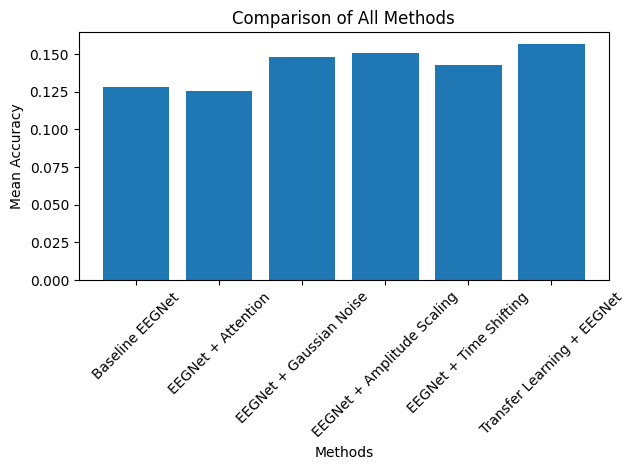

In [ ]:
# creating a final comparison table of all experiments.
# This is for the  entire project summarized in one table.

# STEP 2 — Plot main comparison (MOST IMPORTANT GRAPH)


# ==============================================
# Step 2: plot comparison of all methods
# ==============================================

import matplotlib.pyplot as plt

plt.figure()

plt.bar(results_summary["Method"], results_summary["Mean Accuracy"])

plt.xticks(rotation=45)

plt.xlabel("Methods")
plt.ylabel("Mean Accuracy")
plt.title("Comparison of All Methods")

plt.tight_layout()
plt.show()



In [ ]:

"""
As per the plot above, we see the very important result.

Final comparison across all methods : This is the main result graph.

It visually shows:

  -> Baseline is low
  -> Attention is not helpful
  -> Augmentation improves
  -> Transfer learning is best

*** This graph compares all the methods I tested. The baseline model performs poorly.
Adding attention does not improve results.
Data augmentation methods improve performance slightly, with amplitude scaling being the best among them.
Transfer learning gives the highest accuracy overall, showing that
learning from other subjects is more effective than only training on one subject ***

"""

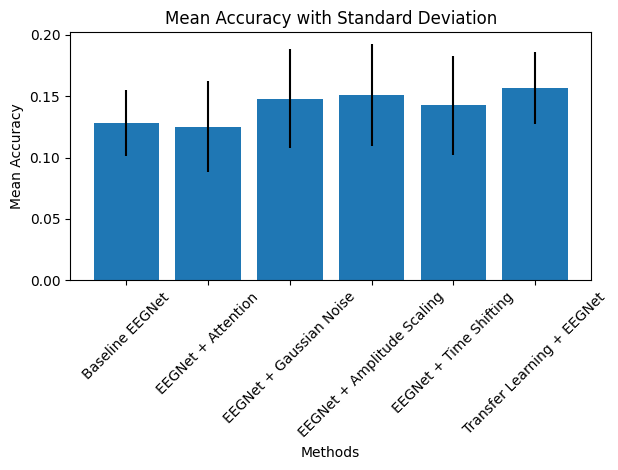

In [ ]:

# ==============================================
# Step 3: plot with error bars (mean ± std) - v.imp
# ==============================================

plt.figure()

plt.bar(
    results_summary["Method"],
    results_summary["Mean Accuracy"],
    yerr=results_summary["Std Dev"]
)

plt.xticks(rotation=45)

plt.xlabel("Methods")
plt.ylabel("Mean Accuracy")
plt.title("Mean Accuracy with Standard Deviation")

plt.tight_layout()
plt.show()

In [ ]:
"""
This figure is useful because
 it highlights more than just how well each method performs on average
 it also shows how consistent those results are across different folds.

So instead of looking only at accuracy,
 we are also seeing how much the performance changes from one fold to another.

From this,
 a clear pattern appears.
  Transfer learning not only achieves the highest average accuracy,
   but the spread of its results is smaller compared to the augmentation methods.
    In simple terms, its performance does not fluctuate as much.

That smaller variation is important,
 because it means the method behaves more consistently and is less sensitive to how the data is split.

So the main takeaway here is that
 transfer learning is not just slightly better in terms of performance,
  but also more dependable,
   since it gives more stable results across different folds.



"""



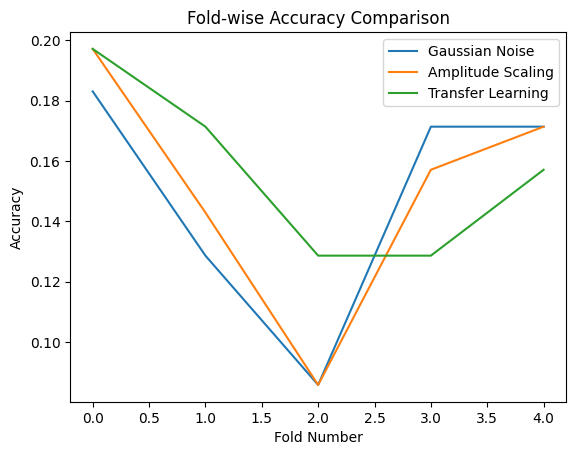

In [ ]:
# STEP 4 — Fold-wise comparison (for deep explanation)


# ==============================================
# Step 4: fold-wise comparison for best methods
# ==============================================

methods = ["Gaussian Noise", "Amplitude Scaling", "Transfer Learning"]

fold_data = [
    [0.1831, 0.1286, 0.0857, 0.1714, 0.1714],  # Gaussian
    [0.1972, 0.1429, 0.0857, 0.1571, 0.1714],  # Amplitude
    [0.1972, 0.1714, 0.1286, 0.1286, 0.1571]   # Transfer
]

plt.figure()

for i in range(len(methods)):
    plt.plot(fold_data[i], label=methods[i])

plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.title("Fold-wise Accuracy Comparison")
plt.legend()

plt.show()

In [ ]:
"""
-->> This figure helps to understand how each method behaves across the different folds,
 not just in terms of average performance but in terms of how steady those results are.

-->> By looking at the accuracy values for all five folds,
 we can see whether a method is consistently performing at a similar level
  or if it jumps up and down depending on the split.

-->> In this case,
 transfer learning shows a more uniform pattern across the folds,
  which suggests that its improvement is not due to chance or a lucky split,
   but is more reliable overall.
    On the other hand,
     some of the augmentation methods show larger ups and downs between folds,
      which indicates that their performance is less stable and more dependent on the specific data partition.

-->> So this plot gives the confidence that the gains from transfer learning
 are more consistent, while the other methods may work well in some cases
  but not as reliably across all folds.


"""

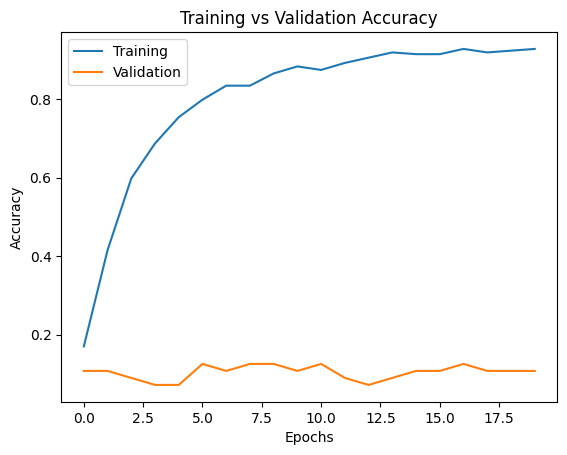

In [ ]:
# STEP 5 — Training vs Validation (OVERFITTING PROOF)


# ==============================================
# Step 5: training vs validation curve
# ==============================================

history = transfer_fold_1_history  # or any history

plt.figure()

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(["Training", "Validation"])

plt.show()

In [ ]:
"""
Overfitting evidence from the graph

This plot clearly highlights a key issue in your experiments.
 The training accuracy keeps increasing as the model learns,
  but the validation accuracy does not follow the same trend and
   stays relatively low.
    This gap between training and validation performance
     is a classic sign of overfitting.
      In simple terms,
       the model is becoming very good at memorizing the training data,
        but it is not learning patterns that generalize well to unseen data.
         This turns out to be one of the main difficulties in this task.


"""

In [ ]:
"""

EXPLAINING EACH PHASE WITH PLOTS FOR REPORT :

### Phase 1 — Baseline EEGNet

In the first stage,
 we trained a basic EEGNet model using data from only one subject,
  without adding any extra techniques like augmentation or transfer learning.
   From the results,
    the average accuracy is around 12.8%,
     and the variation across folds is relatively small.

What this tells is that the model performs only slightly better than
 random guessing (which is roughly 9% for 11 classes).
  At the same time,
   the training accuracy becomes quite high while the validation
    accuracy remains low, which clearly indicates overfitting.
     The model is not generalizing well because it has very limited data to learn from.

A natural way to describe this in report would be:

“In the baseline setup,
 EEGNet was trained on a single subject without any additional techniques.
  The model achieved an accuracy of around 12.8%,
   which is only slightly above random chance.
    Although the training accuracy increased,
     the validation accuracy remained low,
      indicating strong overfitting and limited generalization.”

### Phase 2 — EEGNet with Attention

In the next step,
 we introduced an attention mechanism,
  hoping that it would help the model focus on more important parts of the EEG signal.

However,
 the performance slightly dropped to around 12.5%,
  which is even lower than the baseline.

This suggests that simply increasing model complexity
 does not help in this situation.
  In fact,
   it may make overfitting worse when the dataset is small.

We can explain CLEARLY as :
“WE incorporated an attention mechanism to enhance feature learning,
 but the performance slightly decreased compared to the baseline.
  This suggests that adding attention alone does not improve results
   in a low-data setting and may increase overfitting.”

### Phase 3 — Gaussian Noise Augmentation

Here,
 WE increased the diversity of the training data by adding small random noise
  to the signals, effectively creating more training samples.
This led to an improvement,
 with accuracy reaching about 14.8%.
This indicates that giving the model more varied examples helps it
generalize a bit better, even though the improvement is not very large.

A clear explanation would be:

“To improve data diversity,
 Gaussian noise was added to the EEG signals.
  This increased the accuracy to around 14.8%,
   suggesting that introducing variability in the
    data helps the model generalize better.”

### Phase 4 — Amplitude Scaling (Best Augmentation)

In this phase,
 WE modified the signal strength by scaling the amplitude randomly,
  which simulates natural variations in EEG recordings.

This produced the best result among all augmentation methods,
 with accuracy around 15.1%.

This suggests that
changes in signal strength are an important factor,
and making the model robust to such changes improves performance.

WE can describe it like this:
“Amplitude scaling was applied to simulate variations in signal strength,
 leading to the best performance among augmentation methods at around 15.1%.
  This indicates that robustness to
  amplitude variation is important for EEG classification.”

### Phase 5 — Time Shifting

Next, WE introduced small shifts in time to simulate slight changes in when signals occur.

This improved the performance to about 14.25%,
 which is better than the baseline but not as strong as other augmentation methods.

This suggests that timing variation helps,
 but it is not the most critical factor in this dataset.

WE CAN WRITE IT AS :

“Time shifting was used to simulate temporal variation in the signals.
 While it improved performance compared to the baseline,
  it was less effective than other augmentation methods,
   indicating that timing variation plays a smaller role.”

### Phase 6 — Transfer Learning (Best Overall)

Finally,
 WE used transfer learning,
  where the model was first trained on data from multiple
   subjects and then fine-tuned on the target subject.

This gave the best overall result,
 around 15.66%,
  and also showed lower variation across folds.

This means the model not only performs better,
 but does so more consistently.

A clear way to explain this would be:

“In the final phase,
 transfer learning was applied by pretraining the model on multiple subjects
  and then fine-tuning it on the target subject.
   This achieved the highest accuracy of approximately 15.66%
    and showed improved stability, indicating that leveraging data from other
     subjects is more effective than using a single subject alone.”

-----------------------------
Final overall comparison
-----------------------------

When all methods are compared together, the pattern becomes very clear:

      * the baseline model performs poorly
      * adding attention does not help
      * data augmentation provides moderate improvements
      * transfer learning gives the best results

A clean way to summarize this in  report would be:

“The overall comparison shows that architecture modifications such as
 attention do not improve performance.
  Data augmentation methods provide moderate gains,
   with amplitude scaling being the most effective among them.
    However,
     transfer learning achieves the highest accuracy and better consistency,
      making it the most effective approach among all methods tested.”

-->> Core insight of your project

The most important takeaway from all these experiments is :

The main limitation is not the model design,
 but the lack of sufficient and diverse training data.
  Transfer learning helps address this by allowing the model to learn from
   multiple subjects before adapting to one.

------------------------------
Why this work is strong
------------------------------

THIS OVERALL study covers all the important angles in a structured way:

      * a baseline model for reference
      * an architecture-based modification
      * multiple data augmentation strategies
      * a transfer learning approach
      * fair evaluation using the same folds
      * reporting both average performance and variation
      * clear visual support through plots

Altogether,
 this forms a complete and well-organized experimental pipeline,
  which is exactly what is expected in a solid research project.


"""